# OR게이트 학습 및 시각화 (ANN)

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
import numpy as np

In [31]:
# OR 게이트 
X = torch.FloatTensor([[0,0], [0,1], [1,0], [1,1]])
Y = torch.FloatTensor([[0], [1], [1], [1]])

# 신경망 모델 정의 (입력 2개, 은닉층 2개 뉴런, 출력 1개)
class ORNet(nn.Module):
    def __init__(self):
        super(ORNet, self).__init__()
        self.hidden = nn.Linear(2, 2)    # 은닉층: 입력 2 → 은닉노드 2개
        self.output = nn.Linear(2, 1)    # 출력층: 은닉 2 → 출력 1
        self.sigmoid = nn.Sigmoid()      # 활성화 함수로 시그모이드 
    
    def forward(self, x):
        x = self.sigmoid(self.hidden(x)) # 은닉층 통과 
        x = self.sigmoid(self.output(x)) # 출력층 통과 
        return x

model = ORNet()  

# 손실함수와 옵티마이저 설정
criterion = nn.BCELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

# 학습
losses = []
for epoch in range(5000):
    optimizer.zero_grad()          
    output = model(X)                # 모델의 예측값 계산
    loss = criterion(output, Y)    
    loss.backward()                  # 손실에 따른 기울기(gradient) 계산
    optimizer.step()                
    losses.append(loss.item()) 

# 출력
print("학습 후 예측값:")
print(torch.round(model(X)).detach().numpy())

학습 후 예측값:
[[0.]
 [1.]
 [1.]
 [1.]]


In [32]:
%matplotlib inline

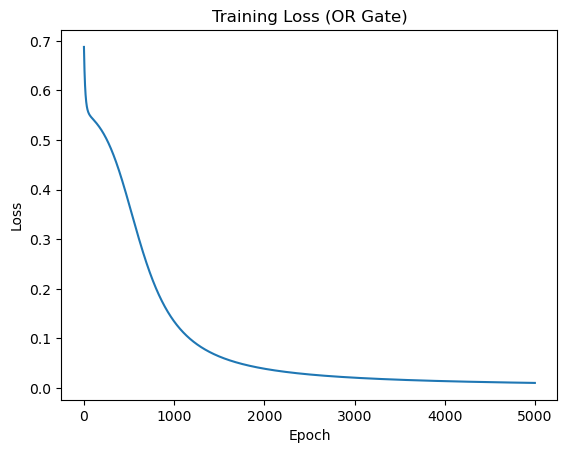

In [33]:
plt.plot(losses)                  # 학습 과정에서 기록한 손실값 그래프
plt.title("Training Loss (OR Gate)") 
plt.xlabel("Epoch")               
plt.ylabel("Loss")                
plt.show()                        

손실함수 그래프에서 처음에는 손실이 높지만, 학습이 진행되며 손실값이 빠르게 감소하고
점점 0에 가까워지며 평평해지는 것을 볼수있다. 모델이 OR 게이트 문제를 잘 학습했다고 볼 수있다.

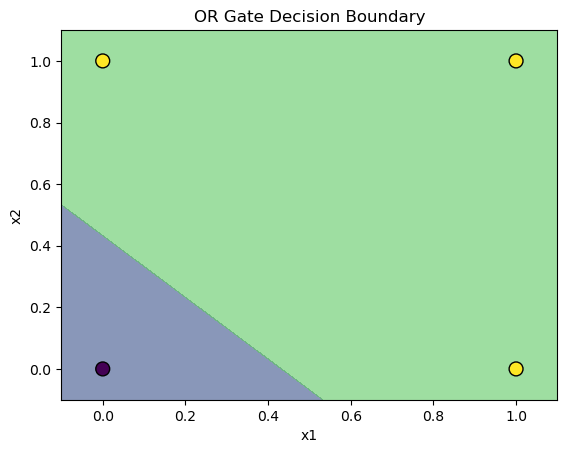

In [35]:
def plot_decision_boundary(model, X, Y):
    x_min, x_max = -0.1, 1.1     # # 입력 데이터의 x, y축 최소/최대값 지정
    y_min, y_max = -0.1, 1.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))     # 100x100 격자점 생성 (결정 경계 시각화용)
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
    with torch.no_grad():        # 신경망의 예측 결과(확률값)를 계산
        probs = model(grid).reshape(xx.shape)
    plt.contourf(xx, yy, probs, alpha=0.6, levels=[0,0.5,1])       # 예측 확률(0~1)에 따라 결정경계를 색으로 표현
    plt.scatter(X[:,0], X[:,1], c=Y[:,0], edgecolors='k', s=100)
    plt.title("OR Gate Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.show()

plot_decision_boundary(model, X, Y)

신경망의 예측 확률에 따라 구분(초록색=1, 남색=0)
노란색 점: 정답이 1인 데이터 (0,1), (1,0), (1,1)
검정 점: 정답이 0인 데이터 (0,0)
경계선(초록색,남색 경계)이  신경망이 OR 문제를 선형적으로 분리함을 확인 할수있다.

# XOR게이트 학습시도 및 한계 시각화 (ANN)

In [37]:
# XOR 게이트 데이터
X = torch.FloatTensor([[0,0], [0,1], [1,0], [1,1]])
Y = torch.FloatTensor([[0], [1], [1], [0]])

# 신경망 (은닉층 1개, 은닉노드 2개)
class XORNet(nn.Module):
    def __init__(self):
        super(XORNet, self).__init__()
        self.hidden = nn.Linear(2, 2)     # 은닉층: 입력 2 → 은닉 2
        self.output = nn.Linear(2, 1)      # 출력층: 은닉 2 → 출력 1
        self.sigmoid = nn.Sigmoid()       # 시그모이드 활성화 함수
    def forward(self, x):
        x = self.sigmoid(self.hidden(x))
        x = self.sigmoid(self.output(x))
        return x

model = XORNet()
criterion = nn.BCELoss()    # 이진 분류용 손실함수
optimizer = optim.SGD(model.parameters(), lr=0.1)   # SGD 옵티마이저(학습률 0.1)

losses = []
for epoch in range(5000):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, Y)
    loss.backward()
    optimizer.step()
    losses.append(loss.item())

print("학습 후 예측값:")
print(torch.round(model(X)).detach().numpy())

학습 후 예측값:
[[0.]
 [0.]
 [1.]
 [0.]]


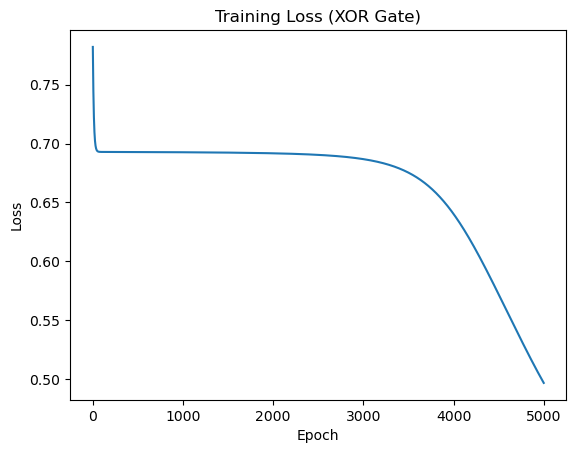

In [38]:
plt.plot(losses)     ## 학습 과정에서 기록한 손실값 그래프
plt.title("Training Loss (XOR Gate)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig('xor_loss.png')
plt.show()

손실이 줄어들긴 하지만 0.5 이하로 잘 내려가지 않고 오랜 시간 동안 학습이 제대로 진행되지 않고 정체.
신경망이 XOR 패턴을 완전히 학습하지 못했을 가능성 존재

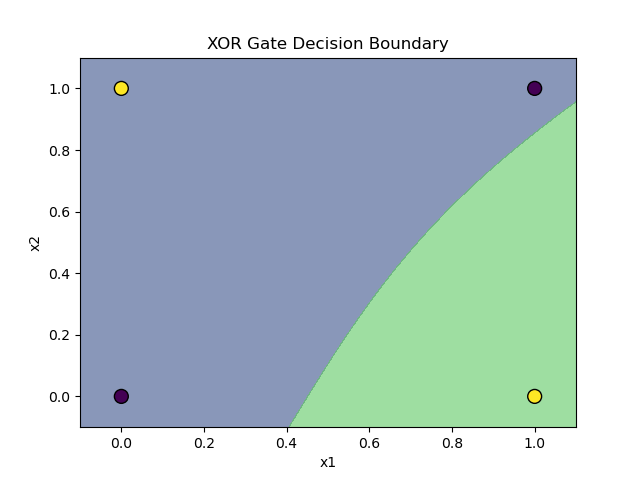

In [39]:
# 결정경계 시각화 
def plot_decision_boundary(model, X, Y):
    x_min, x_max = -0.1, 1.1   # x축의 최소/최대값 지정 
    y_min, y_max = -0.1, 1.1   # y축의 최소/최대값 지정
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])   # 좌표를 신경망 입력 형태(2차원 벡터)로 변환
    with torch.no_grad():              # 신경망에 입력하여 각 점에서의 예측 확률 계산
        probs = model(grid).reshape(xx.shape)
    plt.contourf(xx, yy, probs, alpha=0.6, levels=[0,0.5,1])     # contourf로 0과 1 영역을 색으로 구분 
    plt.scatter(X[:,0], X[:,1], c=Y[:,0], edgecolors='k', s=100)
    plt.title("XOR Gate Decision Boundary")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.savefig('xor_decision_boundary.png')
    plt.close()

plot_decision_boundary(model, X, Y)
from IPython.display import Image, display
display(Image('xor_decision_boundary.png'))

결정경계(색이 바뀌는 경계선)는 곡선 형태이지만 (0,1), (1,0)과 (0,0), (1,1)이 명확하게 나누어지지 않는다.

은닉층 1개(뉴런 2개) 신경망은 사실상 입력 공간을 선형 또는 단순한 곡선으로만 분리할 수 있지만 
XOR 문제는 한 직선, 하나의 비선형 함수로는 분리 불가능한 비선형 분리 문제이기 때문에 분리 불가능하다.
실제로 손실함수를 보면 학습이 제대로 되지 않아 예측 정확도도 낮고 Loss도 높음
이 신경망 구조로는 XOR 게이트를 완벽하게 학습할 수 없다는 것을 알수있다.

# XOR게이트 학습 및 시각화 (DNN)

In [43]:
# XOR 데이터
X = torch.FloatTensor([[0,0], [0,1], [1,0], [1,1]])
Y = torch.FloatTensor([[0], [1], [1], [0]])

# DNN 모델 정의 (은닉층 2개, 각 4노드)
class XOR_DNN(nn.Module):
    def __init__(self):
        super(XOR_DNN, self).__init__()
        self.hidden1 = nn.Linear(2, 4)    # 1번째 은닉층: 입력 2 → 노드 4개
        self.hidden2 = nn.Linear(4, 4)    # 2번째 은닉층: 4 → 4
        self.output = nn.Linear(4, 1)     # 출력층: 4 → 1
        self.sigmoid = nn.Sigmoid()       # 시그모이드(이진분류 확률)
        self.relu = nn.ReLU()             # ReLU(은닉층 활성화)
    def forward(self, x):
        x = self.relu(self.hidden1(x))     # 첫 번째 은닉층 + ReLU
        x = self.relu(self.hidden2(x))      # 두 번째 은닉층 + ReLU
        x = self.sigmoid(self.output(x))      # 출력층 + Sigmoid
        return x

model = XOR_DNN()
criterion = nn.BCELoss()                                  # 이진분류 손실함수
optimizer = optim.Adam(model.parameters(), lr=0.01)       # Adam 옵티마이저 사용

losses = []
for epoch in range(5000):
    optimizer.zero_grad()
    output = model(X)             # 모델 예측값 계산
    loss = criterion(output, Y)       
    loss.backward()               # 기울기(gradient) 계산
    optimizer.step()              # 파라미터 업데이트
    losses.append(loss.item())

print("학습 후 예측값:", torch.round(model(X)).detach().numpy().reshape(-1))

학습 후 예측값: [0. 1. 1. 0.]


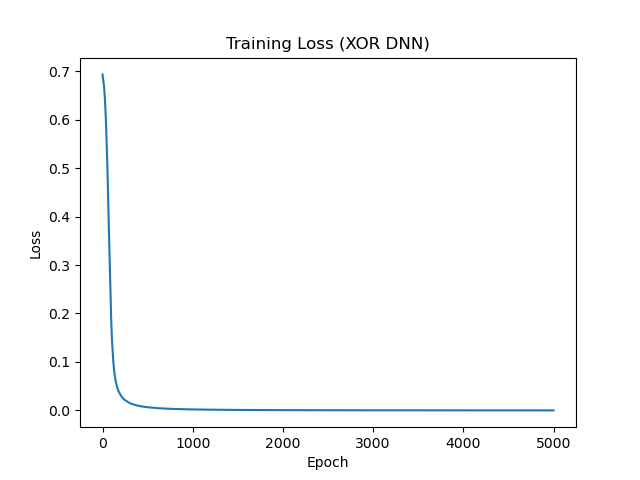

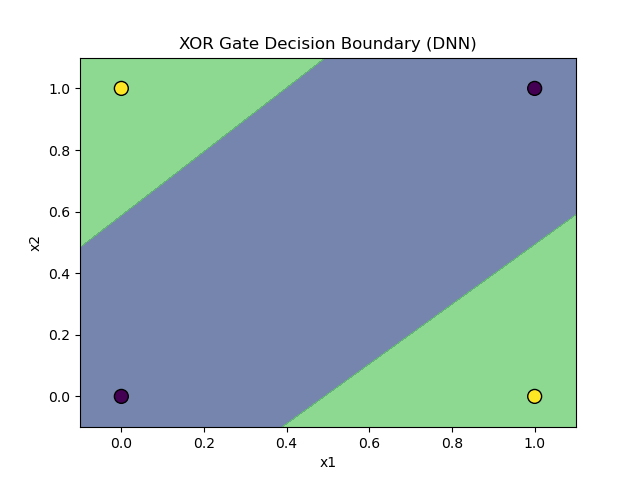

In [44]:
# 손실 그래프 저장 및 확인
plt.plot(losses)
plt.title("Training Loss (XOR DNN)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.savefig('xor_dnn_loss.png')
plt.close()

# 결정경계 시각화 (plt.show 대신 저장)
def plot_decision_boundary(model, X, Y):
    x_min, x_max = -0.1, 1.1          # x축 최소/최대값 
    y_min, y_max = -0.1, 1.1          # y축 최소/최대값
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))
    grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])    # 각 그리드 포인트를 신경망 입력 형식으로 변환
    with torch.no_grad():        # 신경망에 각 포인트를 입력해서 예측 확률(출력)을 계산
        probs = model(grid).reshape(xx.shape)
    plt.contourf(xx, yy, probs, alpha=0.7, levels=[0,0.5,1])    # 예측 확률이 0.5를 기준으로 색칠하여 결정경계 시각화
    plt.scatter(X[:,0], X[:,1], c=Y[:,0], edgecolors='k', s=100)
    plt.title("XOR Gate Decision Boundary (DNN)")
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.savefig('xor_dnn_decision.png')
    plt.close()

plot_decision_boundary(model, X, Y)

from IPython.display import Image, display
display(Image('xor_dnn_loss.png'))
display(Image('xor_dnn_decision.png'))

손실함수 초기에는 손실값이 0.7 이상에서 시작하지만,  빠르게 감소해서 0에 수렴하는 모습을 확인. 
손실이 0에 가까워질수록 신경망이 XOR 데이터 패턴을 거의 완벽하게 학습했다는 의미.

XOR Gate Decision Boundary (DNN) 그래프는 결정경계가 대각선으로 비선형적으로 형성되어
(0,0), (1,1)과 (0,1),(1,0)을 완벽하게 다른 영역으로 분리했음을 알 수있다.

# 분리가 가능한 이유

XOR 문제는 비선형 분리 문제이기 떄문에 입력 공간을 선형으로는 완벽히 분리 불가능하다.
하지만 DNN(은닉층 2개 이상, 비선형 활성화 함수 사용)은 여러 번의 비선형 변환을 통해
입력 공간을 휘어서 복잡한 곡선으로로 0과 1을 분리 가능함.


1. 은닉층에서 ReLU 등 비선형 함수로 입력 공간을 여러 차례 변형

2. 네 개의 포인트를 정확히 0/1 그룹으로 구분 가능

3. 그래프에서 처럼 두 그룹이 완벽히 나뉨